<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/Kaggle_PG_S6E8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
import kagglehub
import joblib
!pip install optuna
import optuna
from scipy.stats import rankdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 17.8 MB/s eta 0:00:00


In [ ]:
# kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

100%|██████████| 19.7M/19.7M [00:00<00:00, 106MB/s] 

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/playground-series-s6e8


In [ ]:
train_df = pd.read_csv(f'{path}/train.csv')
test_df = pd.read_csv(f'{path}/test.csv')

In [ ]:
train_df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [ ]:
train_df.isna().sum()

,0
id,0
age,28929
daily_screen_time_hours,95854
social_media_hours,133995
gaming_hours,126821
work_study_hours,51518
sleep_hours,44480
notifications_per_day,67584
app_opens_per_day,80710
weekend_screen_time,112063


In [ ]:
train_df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [ ]:
train_df.drop(columns = ['id'], inplace = True)

In [ ]:
train_df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [ ]:
train_df['gender'].unique()

array(['Male', 'Female', 'Other', nan], dtype=object)

In [ ]:
train_df['stress_level'].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [ ]:
train_df['academic_work_impact'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
train_df['addicted_label'].unique()

array([1, 0])

In [ ]:
train_df.isna().sum() * 100 / train_df.shape[0]

,0
age,4.184307
daily_screen_time_hours,13.864376
social_media_hours,19.381112
gaming_hours,18.343461
work_study_hours,7.451592
sleep_hours,6.433612
notifications_per_day,9.775388
app_opens_per_day,11.673940
weekend_screen_time,16.208855
gender,4.199494


In [ ]:
train_df.columns

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level',
       'academic_work_impact', 'addicted_label'],
      dtype='object')

In [ ]:
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time']
cat_cols = ['gender', 'academic_work_impact']
cat_to_num_cols = ['stress_level']

In [ ]:
train_df['stress_level'].value_counts(normalize = True, dropna = False)

,proportion
stress_level,
High,0.319472
Low,0.300538
Medium,0.300223
NaN,0.079766


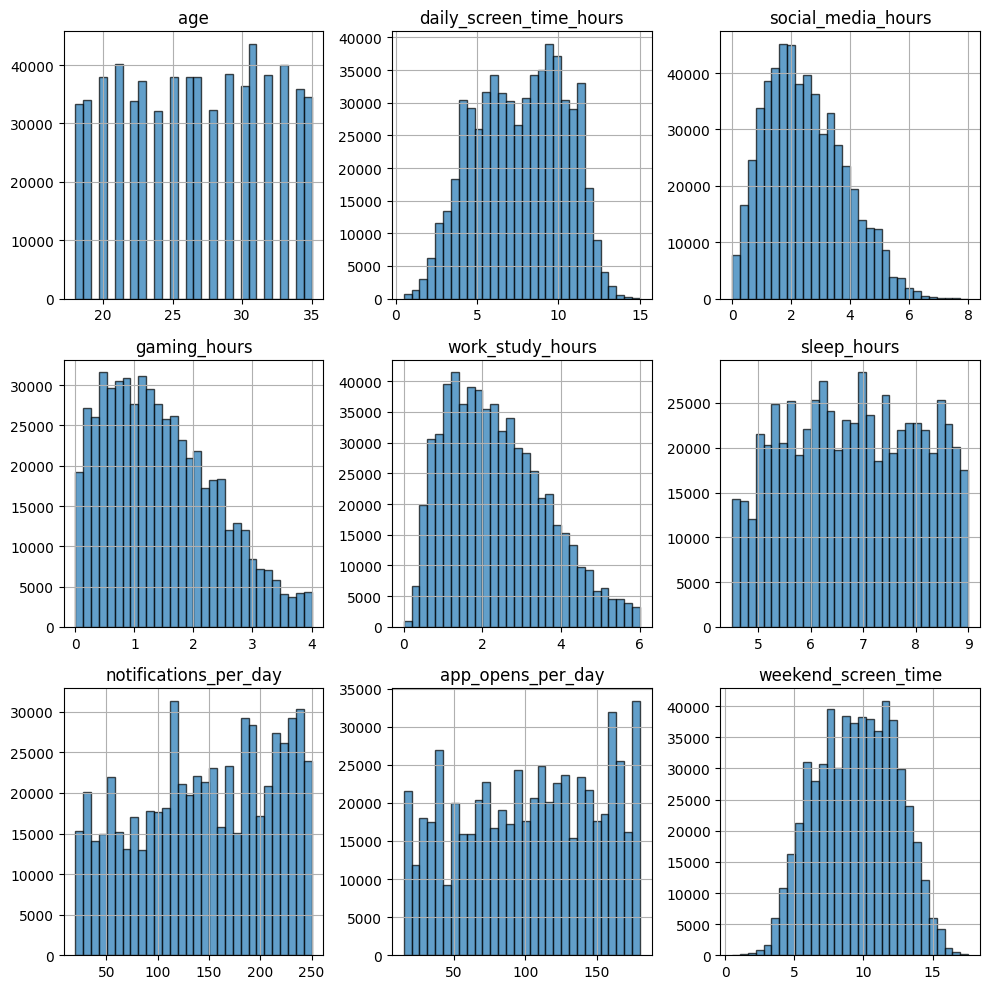

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.hist(train_df[num_cols[i]], bins=30, edgecolor="black", alpha=0.7)
    ax.set_title(f"{num_cols[i]}")
    ax.grid(True)

plt.tight_layout()
plt.show()

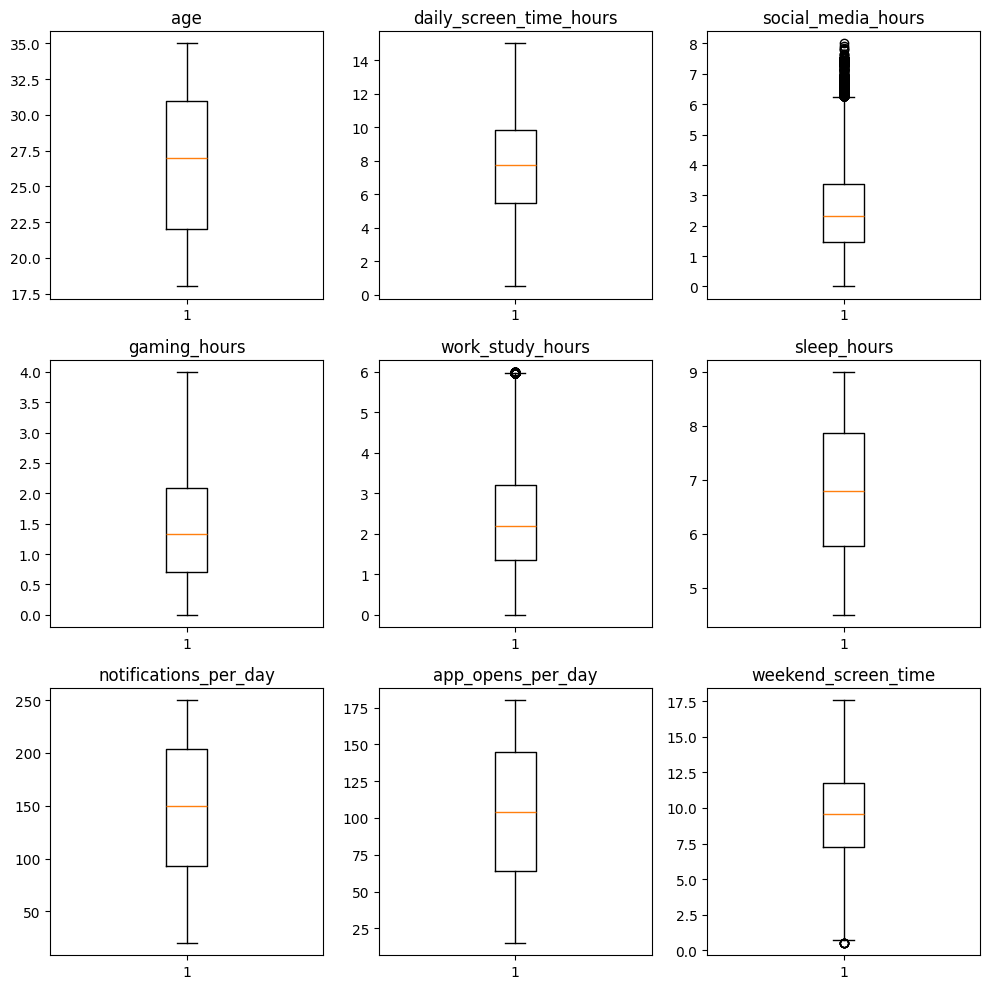

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.boxplot(train_df[num_cols[i]].dropna())
    ax.set_title(f"{num_cols[i]}")

plt.tight_layout()
plt.show()

/tmp/ipykernel_719/3238027278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=cat_cols[i], ax=axes[i], palette='Set1')
/tmp/ipykernel_719/3238027278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=cat_cols[i], ax=axes[i], palette='Set1')


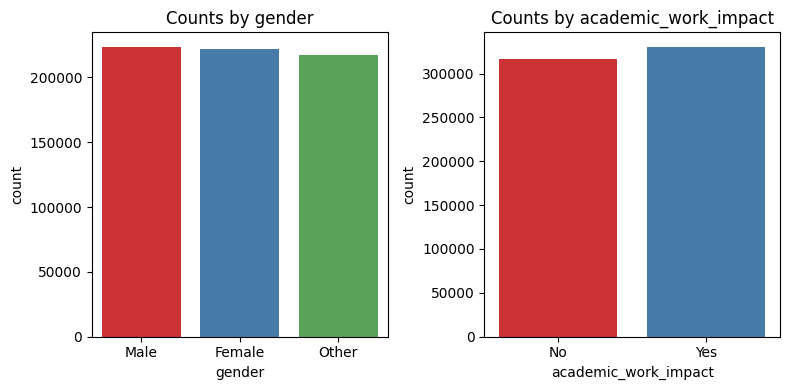

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i in range(2):
  sns.countplot(data=train_df, x=cat_cols[i], ax=axes[i], palette='Set1')
  axes[i].set_title(f'Counts by {cat_cols[i]}')

plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='stress_level'>

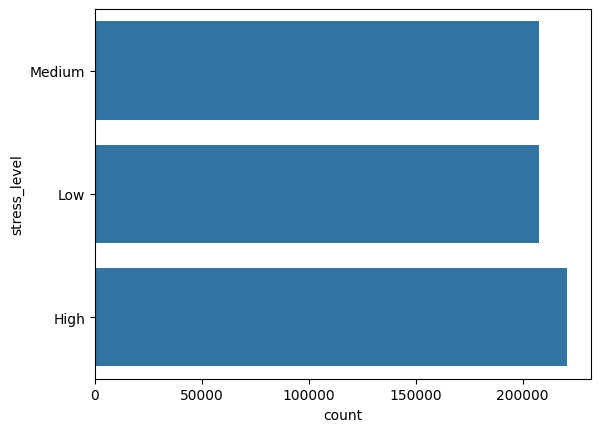

In [ ]:
sns.countplot(train_df['stress_level'])

<Axes: >

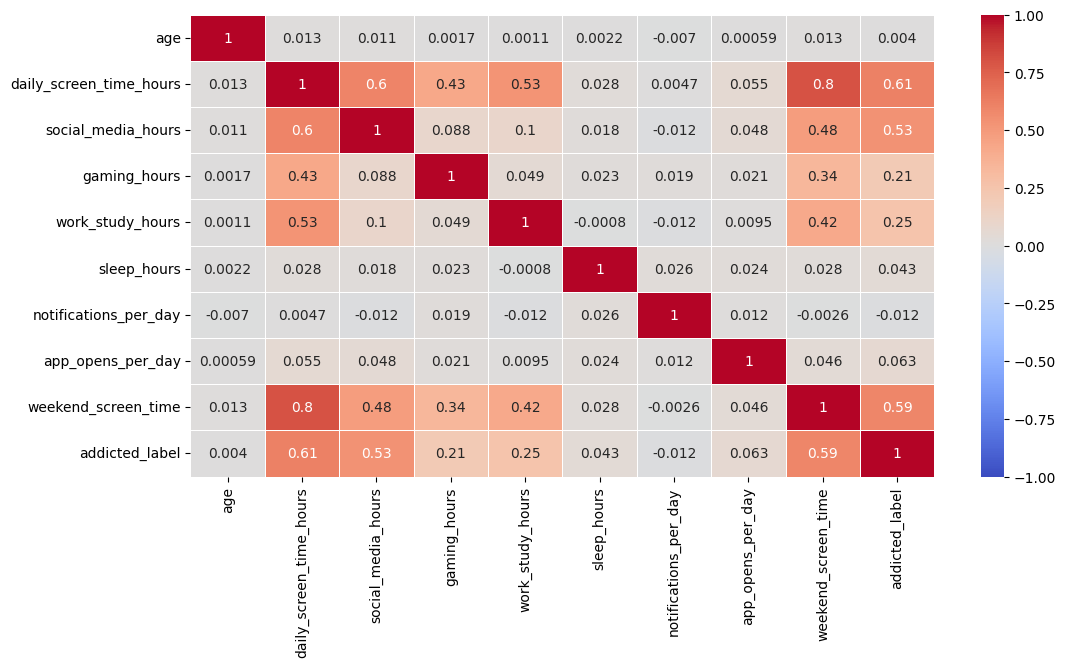

In [ ]:
corr_matrix = train_df.corr(numeric_only = True)

plt.figure(figsize = (12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

In [ ]:
train_df['addicted_label'].value_counts(normalize = True)

,proportion
addicted_label,
1,0.709424
0,0.290576


## The Master Preprocessing Order of Operations

[ RAW DATASET ]
       │
       ▼
 1. TRAIN / TEST SPLIT              --> Done FIRST to isolate the Test Set completely.
       │
┌──────┴───────────────────────────┐│
▼   
TRAINING SET ONLY

 2. LOG / BOX-COX TRANSFORMATION   --> Fixes skewness on raw numbers before imputation.
       │
       ▼

 3. ORDINAL ENCODING (MANUAL)      --> Maps ordered text (e.g., Stress Level) to raw integers.
       │
       ▼

 4. IMPUTATION                     --> Fills all NaN values (Median, Mode, or KNN Imputer).
       │
       ▼

 5. NOMINAL ENCODING               --> One-Hot Encodes unordered text features into 0s and 1s.
       │
       ▼

 6. OUTLIER PROCESSING             --> Caps or removes outliers from the clean, imputed data.
       │
       ▼

 7. FEATURE SCALING                --> Normalizes features (Standard/MinMax). Crucial before SMOTE!
       │
       ▼

 8. SMOTE (OVERSAMPLING)           --> Balances target classes. Must be the ABSOLUTE LAST step.
       │
       ▼

[ READY FOR ML MODEL TRAINING ]

# Preprocessing

Five types of steps -

1. Without KNN ->

  a. Tranformation

  b. Mapping -> stress_level column to be mapped
   stress_level column -> Median imputation

  c. Imputation ->
    Numerical columns -> Median imputation
    Categorical column -> Create new unknown category
   

  d. Encoding ->
    One hot encoding
  
  e. Outlier Processing ->
    Social Media Hours, Work study hours (Capping)

  f. Scaling

  g. SMOTE

  h. Model Building

2. With KNN ->

  a. Tranformation

  b. Mapping -> stress_level column to be mapped

  c. Imputation ->
    Categorical column -> Create new unknown category

  d. Encoding ->
    One hot encoding

  e. Scaling

  f. Imputation ->
    Numerical column -> KNN Imputer
  
  g. Outlier Processing ->
    Social Media Hours, Work study hours (Capping)

  h. SMOTE

  i. Model Building

3. Feature engineering can be done at the very beginning if the new features are getting extracted from a single column. But if the new feature is getting obtained after interaction of some features it should be done just after imputation.

4. To use outlier algorithms and then selectively build model on non-outlier points pipeline will be different ->

                      [ RAW TRAIN DATA ]
                               │
                               ▼
        ┌──────────────────────────────────────────────┐
        │  PIPELINE 1: INITIAL PREPROCESSING & SCALING │
        └──────────────────────────────────────────────┘
                               │
                               ▼
                    [ CLEAN NUMERIC ARRAY ]
                               │
                               ▼
        ┌──────────────────────────────────────────────┐
        │       MANUAL STEP: OUTLIER FILTERING         │
        │  • Train IF or LOF on the numeric array      │
        │  • Filter out rows flagged as -1 (outliers)  │
        └──────────────────────────────────────────────┘
                               │
                               ▼
                  [ NO-OUTLIERS NUMERIC ARRAY ]
                               │
                               ▼
        ┌──────────────────────────────────────────────┐
        │         PIPELINE 2: SMOTE ONLY               │
        └──────────────────────────────────────────────┘
                               │
                               ▼
                 [ READY FOR ML MODEL TRAINING ]

5. To use dimensionality reduction also the pipeline will look like this ->

                  [ RECTIFIED NUMERIC MATRIX ]
                               │
                               ▼
        ┌──────────────────────────────────────────────┐
        │ 1. PIPELINE 1: INITIAL PREPROCESSING & SCALING │--> Normalises ranges (Crucial for distance math)                   
        └──────────────────────────────────────────────┘
                               │
                               ▼
          ┌──────────────────────────────────────────────┐
           │ 2. DIMENSIONALITY REDUCTION (e.g., PCA)      │ --> Reduces dimensions while preserving variance
           └──────────────────────────────────────────────┘
                               │
                               ▼
        ┌──────────────────────────────────────────────┐
        │ 3. OUTLIER DETECTION (IF / LOF)              │ --> Drops noise columns in the new low-dim space
        └──────────────────────────────────────────────┘
                               │
                               ▼
        ┌──────────────────────────────────────────────┐
        │ 4. SMOTE (OVERSAMPLING)                      │ --> Synthesises samples along clear geometric axes
        └──────────────────────────────────────────────┘
                               │
                               ▼
                        [ MODEL TRAINING ]

In [ ]:
class CustomOrdinalMapper(BaseEstimator, TransformerMixin):
    """Maps ordered strings to numbers. Preserves NaNs cleanly if requested."""
    def __init__(self, mapping, keep_nans=False):
        self.mapping = mapping
        self.keep_nans = keep_nans
        self.median_ = None

    def fit(self, X, y=None):
        if not self.keep_nans:
            series = X.squeeze().map(self.mapping)
            self.median_ = series.median()
        return self

    def transform(self, X):
        X_mapped = X.squeeze().map(self.mapping)
        if self.keep_nans:
            return X_mapped.values.reshape(-1, 1)
        else:
            return X_mapped.fillna(self.median_).values.reshape(-1, 1)

class OutlierCapper(BaseEstimator, TransformerMixin):
    """Performs continuous numeric clipping using strictly integer positions."""
    def __init__(self, positions_to_cap, factor=1.5):
        self.positions_to_cap = positions_to_cap
        self.factor = factor
        self.bounds_ = {}

    def fit(self, X, y=None):
        X_arr = np.asarray(X)
        self.bounds_ = {}
        for pos in self.positions_to_cap:
            col_data = X_arr[:, pos]
            q1 = np.nanquantile(col_data, 0.25)
            q3 = np.nanquantile(col_data, 0.75)
            iqr = q3 - q1
            self.bounds_[pos] = {
                'lower': q1 - (self.factor * iqr),
                'upper': q3 + (self.factor * iqr)
            }
        return self

    def transform(self, X):
        X_arr = np.asarray(X).copy()
        for pos in self.positions_to_cap:
            X_arr[:, pos] = np.clip(
                X_arr[:, pos],
                self.bounds_[pos]['lower'],
                self.bounds_[pos]['upper']
            )
        return X_arr

class NumericalFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Adds new interaction features from numerical columns.
    Assumes input X is a NumPy array, where the initial columns correspond
    to the original numerical features specified by `original_num_cols`.
    """
    def __init__(self, original_num_cols):
        self.original_num_cols = original_num_cols
        self.n_original_num_cols = len(original_num_cols)

        # Store relative indices for features within the numerical block
        self.daily_screen_time_idx = self.original_num_cols.index('daily_screen_time_hours')
        self.social_media_hours_idx = self.original_num_cols.index('social_media_hours')
        self.gaming_hours_idx = self.original_num_cols.index('gaming_hours')
        self.work_study_hours_idx = self.original_num_cols.index('work_study_hours')
        self.sleep_hours_idx = self.original_num_cols.index('sleep_hours')
        self.notifications_per_day_idx = self.original_num_cols.index('notifications_per_day')
        self.app_opens_per_day_idx = self.original_num_cols.index('app_opens_per_day')
        self.weekend_screen_time_idx = self.original_num_cols.index('weekend_screen_time')

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Extract the numerical part of X, assuming it's at the beginning
        X_num_part = X[:, :self.n_original_num_cols]

        # Work on a copy of the numerical part
        X_transformed_num = X_num_part.copy()

        # Example Feature 1: Total Engagement (combining various screen times and work/study)
        total_engagement_hours = (
            X_transformed_num[:, self.daily_screen_time_idx] +
            X_transformed_num[:, self.social_media_hours_idx] +
            X_transformed_num[:, self.gaming_hours_idx] +
            X_transformed_num[:, self.work_study_hours_idx] +
            X_transformed_num[:, self.weekend_screen_time_idx]
        )

        # Example Feature 2: Productivity Ratio (work/study hours vs. daily screen time)
        # Add a small constant to prevent division by zero
        productivity_ratio = X_transformed_num[:, self.work_study_hours_idx] / \
                             (X_transformed_num[:, self.daily_screen_time_idx] + 1e-6)

        # Example Feature 3: Screen Time per Notification
        screen_time_per_notification = X_transformed_num[:, self.daily_screen_time_idx] / \
                                       (X_transformed_num[:, self.notifications_per_day_idx] + 1e-6)

        # Combine original numerical features with new features
        X_num_with_new_features = np.c_[X_transformed_num, total_engagement_hours, productivity_ratio, screen_time_per_notification]

        # If X was originally the combined array (from KNN pipeline), we re-combine with non-numerical parts
        if X.shape[1] > self.n_original_num_cols:
            X_cat_ord_part = X[:, self.n_original_num_cols:]
            return np.c_[X_num_with_new_features, X_cat_ord_part]
        else: # X was just the numerical part (from simple pipeline num_track)
            return X_num_with_new_features

In [ ]:
def get_simple_pipeline(num_cols, cat_cols, cat_to_num_cols, stress_mapping):
    num_track = Pipeline([
        ('log', FunctionTransformer(np.log1p, validate=False)),
        ('median', SimpleImputer(strategy='median')),
        ('fe', NumericalFeatureEngineer(original_num_cols=num_cols)) # Feature Engineering after imputation
    ])
    cat_track = Pipeline([
        ('unk', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    ord_track = Pipeline([('map', CustomOrdinalMapper(stress_mapping, keep_nans=False))])

    preprocessor = ColumnTransformer([
        ('num', num_track, num_cols),
        ('cat', cat_track, cat_cols),
        ('ord', ord_track, cat_to_num_cols)
    ])
    return Pipeline([('prep', preprocessor), ('scale', StandardScaler())])

def get_knn_pipeline(num_cols, cat_cols, cat_to_num_cols, stress_mapping):
    # For KNN, feature engineering will be applied after KNNImputer in the main loop
    num_track = Pipeline([('log', FunctionTransformer(np.log1p, validate=False))])
    cat_track = Pipeline([
        ('unk', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    ord_track = Pipeline([('map', CustomOrdinalMapper(stress_mapping, keep_nans=True))])

    preprocessor = ColumnTransformer([
        ('num', num_track, num_cols),
        ('cat', cat_track, cat_cols),
        ('ord', ord_track, cat_to_num_cols)
    ])
    return Pipeline([('prep', preprocessor), ('scale', StandardScaler())])

# Helper function for applying FE after KNN imputation
def apply_numerical_feature_engineering_knn(X_train, X_val, X_test, original_num_cols, num_features_after_ohe):
    # The NumericalFeatureEngineer needs to know the original numerical column names
    # and the total number of features (original numerical + one-hot encoded + ordinal)
    # to correctly slice the array when applied after ColumnTransformer + KNNImputer.

    # The NumericalFeatureEngineer is designed to work by taking the initial `n_original_num_cols`
    # columns as its base numerical features, and then re-combining with the rest of the array.
    fe = NumericalFeatureEngineer(original_num_cols=original_num_cols)

    X_train_fe = fe.transform(X_train)
    X_val_fe = fe.transform(X_val)
    X_test_fe = fe.transform(X_test)

    return X_train_fe, X_val_fe, X_test_fe

With the `NumericalFeatureEngineer` defined, we need to adjust the `positions_to_cap` for `OutlierCapper` to include the new features. Since we're adding 3 new features, the total count of numerical features will increase.

In [ ]:
X = train_df.drop(columns = ['addicted_label'])
y = train_df.iloc[:, -1]
X_test = test_df.drop(columns = ['id'])

stress_mapping = {'Low': 1, 'Medium': 2, 'High': 3}

# Adjust positions_to_cap to include new features
# Original numerical features + 3 new features = len(num_cols) + 3
NUM_NEW_FEATURES = 3 # Number of features added by NumericalFeatureEngineer
adjusted_positions_to_cap = list(range(len(num_cols) + NUM_NEW_FEATURES))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

simple_cache, knn_cache = {}, {}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    # --- PIPELINE 1: SIMPLE IMPUTER EXECUTION (now with Feature Engineering) ---
    pipe_simple = get_simple_pipeline(num_cols, cat_cols, cat_to_num_cols, stress_mapping)
    X_tr_s = pipe_simple.fit_transform(X_tr)
    X_va_s = pipe_simple.transform(X_va)
    X_te_s = pipe_simple.transform(X_test)

    # OutlierCapper now uses adjusted_positions_to_cap
    capper_s = OutlierCapper(positions_to_cap=adjusted_positions_to_cap, factor=1.5).fit(X_tr_s)
    simple_cache[f'fold_{fold}'] = {
        'X_train': capper_s.transform(X_tr_s), 'y_train': y_tr.values,
        'X_val': capper_s.transform(X_va_s), 'y_val': y_va.values,
        'X_test': capper_s.transform(X_te_s),
        'train_idx': train_idx, 'val_idx': val_idx
    }

    # # --- PIPELINE 2: KNN IMPUTER EXECUTION (now with Feature Engineering after KNN Imputation) ---
    # pipe_knn = get_knn_pipeline(num_cols, cat_cols, cat_to_num_cols, stress_mapping)
    # X_tr_k = pipe_knn.fit_transform(X_tr)
    # X_va_k = pipe_knn.transform(X_va)
    # X_te_k = pipe_knn.transform(X_test)

    # knn_engine = KNNImputer(n_neighbors=3).fit(X_tr_k)
    # X_tr_k = knn_engine.transform(X_tr_k)
    # X_va_k = knn_engine.transform(X_va_k)
    # X_te_k = knn_engine.transform(X_te_k)

    # # Apply Feature Engineering manually after KNN Imputation
    # X_tr_k, X_va_k, X_te_k = apply_numerical_feature_engineering_knn(X_tr_k, X_va_k, X_te_k, num_cols, X_tr_k.shape[1])

    # # OutlierCapper now uses adjusted_positions_to_cap
    # capper_k = OutlierCapper(positions_to_cap=adjusted_positions_to_cap, factor=1.5).fit(X_tr_k)
    # knn_cache[f'fold_{fold}'] = {
    #     'X_train': capper_k.transform(X_tr_k), 'y_train': y_tr.values,
    #     'X_val': capper_k.transform(X_va_k), 'y_val': y_va.values,
    #     'X_test': capper_k.transform(X_te_k),
    #     'train_idx': train_idx, 'val_idx': val_idx
    # }
    # print(f"Fold {fold} arrays cached successfully.")

# Standardize serialization using joblib files
joblib.dump(simple_cache, 'simple_cache.pkl')
# joblib.dump(knn_cache, 'knn_cache.pkl') # Uncommment this to save KNN cache
print("\nPhase 1 Complete: All preprocessing variations saved safely!")

In [ ]:
# Use joblib to seamlessly parse input configurations
simple_data = joblib.load('simple_cache.pkl')
# knn_data = joblib.load('knn_cache.pkl')

In [ ]:
def evaluate_lr_baseline(data_cache, name="Simple Imputer"):
    oof_preds = np.zeros(len(y))
    test_preds_folds = np.zeros((test_df.shape[0], 5))

    fold_scores = []

    for fold in range(5):
        f_data = data_cache[f'fold_{fold}']
        val_idx = f_data['val_idx']

        # Apply SMOTE to the balanced array space right before fitting
        smote = SMOTE(random_state=42)
        X_tr_res, y_tr_res = smote.fit_resample(f_data['X_train'], f_data['y_train'])

        # Process Linear baseline
        lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver='saga')
        lr.fit(X_tr_res, y_tr_res)

        # Safely record predictions mapping directly back to original validation coordinates
        val_probs = lr.predict_proba(f_data['X_val'])[:, 1]
        oof_preds[val_idx] = val_probs

        test_preds_folds[:, fold] = lr.predict_proba(f_data['X_test'])[:, 1]

        # Score verification per iteration loop
        fold_auc = roc_auc_score(f_data['y_val'], val_probs)
        fold_scores.append(fold_auc)

    print(f"Overall OOF ROC-AUC [{name} Layout]: {roc_auc_score(y, oof_preds):.5f}")
    print(f"Mean Fold ROC-AUC [{name} Layout]: {np.mean(fold_scores):.5f}\n")

    return oof_preds, test_preds_folds.mean(axis=1)

In [ ]:
print("--- Evaluating Baseline Alignments ---")

print("--- Simple Imputer ---")
simple_oof, test_preds = evaluate_lr_baseline(simple_data, name="Simple Imputer")

# print("--- KNN Imputer ---")
# knn_oof = evaluate_lr_baseline(knn_data, name="KNN Imputer")

--- Evaluating Baseline Alignments ---
--- Simple Imputer ---
Overall OOF ROC-AUC [Simple Imputer Layout]: 0.90878
Mean Fold ROC-AUC [Simple Imputer Layout]: 0.90878



In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "addicted_label": test_preds
})
submission.to_csv("submission_ensemble.csv", index=False)
print("Ensemble execution complete! Final test predictions exported to 'submission_ensemble.csv'.")

Ensemble execution complete! Final test predictions exported to 'submission_ensemble.csv'.


In [ ]:
# # Silence Optuna verbose logging for clean console output
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# # ==========================================
# # 1. SETUP GLOBAL CONFIGURATIONS
# # ==========================================
# # Load caches generated from Phase 1
# simple_cache = joblib.load('simple_cache.pkl')
# # knn_cache = joblib.load('knn_cache.pkl')

# train_raw = train_df.copy()
# y_train_global = train_raw["addicted_label"].values

# # Test set placeholder sizes based on cached structural lengths
# n_test = len(simple_cache['fold_0']['X_test'])

# # ==========================================
# # 2. OPTUNA HYPERPARAMETER TUNING ENGINES
# # ==========================================
# def optimize_lgbm(trial, cache_data):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1
#     }

#     val_scores = []
#     for fold in range(5):
#         f_data = cache_data[f'fold_{fold}']
#         smote = SMOTE(random_state=42)
#         X_res, y_res = smote.fit_resample(f_data['X_train'], f_data['y_train'])

#         model = LGBMClassifier(**params)
#         model.fit(X_res, y_res)

#         preds = model.predict_proba(f_data['X_val'])[:, 1]
#         val_scores.append(roc_auc_score(f_data['y_val'], preds))

#     return np.mean(val_scores)

# def optimize_xgb(trial, cache_data):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
#         'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
#         'random_state': 42,
#         'n_jobs': -1,
#         'eval_metric': 'logloss'
#     }

#     val_scores = []
#     for fold in range(5):
#         f_data = cache_data[f'fold_{fold}']
#         smote = SMOTE(random_state=42)
#         X_res, y_res = smote.fit_resample(f_data['X_train'], f_data['y_train'])

#         model = XGBClassifier(**params)
#         model.fit(X_res, y_res)

#         preds = model.predict_proba(f_data['X_val'])[:, 1]
#         val_scores.append(roc_auc_score(f_data['y_val'], preds))

#     return np.mean(val_scores)

# # ==========================================
# # 3. UNIFIED OOF CROSS-VALIDATION RUNNER
# # ==========================================
# def train_oof_predictions(model_class, model_params, cache_data):
#     """Trains a model across all folds to build clean OOF validation and test predictions."""
#     oof_preds = np.zeros(len(y_train_global))
#     test_preds_folds = np.zeros((n_test, 5))

#     for fold in range(5):
#         f_data = cache_data[f'fold_{fold}']
#         val_idx = f_data['val_idx']

#         smote = SMOTE(random_state=42)
#         X_res, y_res = smote.fit_resample(f_data['X_train'], f_data['y_train'])

#         model = model_class(**model_params)
#         model.fit(X_res, y_res)

#         # Out-of-fold validation mapping
#         oof_preds[val_idx] = model.predict_proba(f_data['X_val'])[:, 1]
#         # Test collection per fold
#         test_preds_folds[:, fold] = model.predict_proba(f_data['X_test'])[:, 1]

#     return oof_preds, test_preds_folds.mean(axis=1)

In [ ]:
# # ==========================================
# # 4. EXECUTION PIPELINE
# # ==========================================

# # Optimize LightGBM on Simple Imputer Pipeline Data
# print("Optimizing LightGBM (Simple Imputer)...")
# study_lgb = optuna.create_study(direction="maximize")
# study_lgb.optimize(lambda t: optimize_lgbm(t, simple_cache), n_trials=15)
# best_lgb_params = study_lgb.best_params
# best_lgb_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})
# print(f"-> Best LGBM CV Score: {study_lgb.best_value:.5f}")

# # Optimize XGBoost on KNN Imputer Pipeline Data
# print("Optimizing XGBoost (KNN Imputer)...")
# study_xgb = optuna.create_study(direction="maximize")
# study_xgb.optimize(lambda t: optimize_xgb(t, simple_cache), n_trials=15)
# best_xgb_params = study_xgb.best_params
# best_xgb_params.update({'random_state': 42, 'n_jobs': -1, 'eval_metric': 'logloss'})
# print(f"-> Best XGB CV Score: {study_xgb.best_value:.5f}\n")

# print("--- STEP 2: GENERATING META-FEATURES ---")
# # Base Model 1: Logistic Regression Baseline (Simple Cache)
# lr_params = {'max_iter': 1000, 'C': 1.0, 'random_state': 42, 'solver': 'saga'}
# oof_lr, test_lr = train_oof_predictions(LogisticRegression, lr_params, simple_cache)

# # Base Model 2: Optimized LightGBM (Simple Cache)
# oof_lgb, test_lgb = train_oof_predictions(LGBMClassifier, best_lgb_params, simple_cache)

# # Base Model 3: Optimized XGBoost (Simple Cache)
# oof_xgb, test_xgb = train_oof_predictions(XGBClassifier, best_xgb_params, simple_cache)

# # ==========================================
# # 5. THE BLENDING STRATEGY (Rank Averaging)
# # ==========================================
# print("--- STEP 3: EVALUATING RANK-AVERAGED BLEND ---")
# # Convert probabilities to uniform percentile ranks to protect against uneven scaling anomalies
# oof_lgb_rank = rankdata(oof_lgb) / len(oof_lgb)
# oof_xgb_rank = rankdata(oof_xgb) / len(oof_xgb)

# # Simple Rank-Weighted Blend: Give slightly more priority to your superior non-linear models
# oof_blend_rank = (0.50 * oof_lgb_rank) + (0.50 * oof_xgb_rank)
# blend_auc = roc_auc_score(y_train_global, oof_blend_rank)
# print(f"Rank Blend OOF ROC-AUC: {blend_auc:.5f}\n")

# # Transform test targets for production mapping deployment
# test_lgb_rank = rankdata(test_lgb) / len(test_lgb)
# test_xgb_rank = rankdata(test_xgb) / len(test_xgb)
# test_blend_rank = (0.50 * test_lgb_rank) + (0.50 * test_xgb_rank)

# # ==========================================
# # 6. THE STACKING STRATEGY (Meta-Learner)
# # ==========================================
# print("--- STEP 4: TRAINING META-STACKER ---")
# # Construct structural data matrix frameworks built entirely from base model OOF properties
# X_meta_train = np.column_stack([oof_lr, oof_lgb, oof_xgb])
# X_meta_test = np.column_stack([test_lr, test_lgb, test_xgb])

# # Train Logistic Regression meta-learner using cross-validation to prevent meta-leakage
# meta_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# meta_oof_preds = np.zeros(len(y_train_global))
# meta_test_preds_folds = np.zeros((n_test, 5))

# # We use basic Stratified K-Fold splits mapping to match indices cleanly
# from sklearn.model_selection import StratifiedKFold
# skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# for fold, (m_train_idx, m_val_idx) in enumerate(skf_meta.split(X_meta_train, y_train_global)):
#     X_m_tr, y_m_tr = X_meta_train[m_train_idx], y_train_global[m_train_idx]
#     X_m_va = X_meta_train[m_val_idx]

#     # Keep meta-model simple to avoid overfitting meta-predictions (L2 regularised ridge)
#     meta_model = LogisticRegression(C=0.1, random_state=42)
#     meta_model.fit(X_m_tr, y_m_tr)

#     meta_oof_preds[m_val_idx] = meta_model.predict_proba(X_m_va)[:, 1]
#     meta_test_preds_folds[:, fold] = meta_model.predict_proba(X_meta_test)[:, 1]

# stack_auc = roc_auc_score(y_train_global, meta_oof_preds)
# final_stack_test_preds = meta_test_preds_folds.mean(axis=1)
# print(f"Meta-Stacker OOF ROC-AUC: {stack_auc:.5f}\n")

Optimizing LightGBM (Simple Imputer)...


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

In [ ]:
# ==========================================
# 7. EXPORT TEST PREDICTIONS
# ==========================================
# Choose final design setup based on empirical local score optimization prints

# final_predictions = final_stack_test_preds if stack_auc > blend_auc else test_blend_rank

# submission = pd.DataFrame({
#     "id": test_raw["id"],
#     "addicted_label": final_predictions
# })
# submission.to_csv("submission_ensemble.csv", index=False)
# print("Ensemble execution complete! Final test predictions exported to 'submission_ensemble.csv'.")